<h1 align="center"> Image Captioning (10 баллов) </h1>

В этом ноутбуке вы обучите сеть составлять подписи к изображениям.
![img](https://i.imgur.com/obITaMl.png)


#### План работы:

1. Использовать предобученную модель Inception v3 для преобразования изображений в векторы.

2. Добавить поверх неё LSTM.

3. Обучить модель на датасете [MSCOCO](http://cocodataset.org/#download).

### 1. Данные (0.5 балла)

In [44]:
# Скачайте датасет по ссылке https://drive.google.com/file/d/1j3Pey7vhGA5_OYrjos-gDwv5_gm7BPBO/view?usp=sharing

In [45]:
# !gdown "https://drive.google.com/uc?id=1j3Pey7vhGA5_OYrjos-gDwv5_gm7BPBO" -O handout.tar.gz

In [46]:
# !tar -xvzf handout.tar.gz

In [47]:
!rm -rf handout.tar.gz

In [64]:
import numpy as np
import json

In [ ]:
%%time
# Read Dataset

img_codes = np.load("data/image_codes.npy")
captions = json.load(open('data/captions_tokenized.json'))

CPU times: user 106 ms, sys: 217 ms, total: 322 ms
Wall time: 323 ms



Чтобы сэкономить ваше время, мы уже преобразовали все изображения из MSCOCO17 в векторы с помощью предобученной сети Inception_v3 из библиотеки [torchvision](https://github.com/pytorch/vision/blob/master/torchvision/models/inception.py).

Весь процесс занимает от одного дня на CPU до примерно 10 минут на трёх GPU Tesla M40. [Если хотите попробовать сделать это самостоятельно — пожалуйста.](https://gist.github.com/justheuristic/11fd01f9c12c0bf960499580d104130b).


In [49]:
print("Each image code is a 2048-unit vector [ shape: %s ]" % str(img_codes.shape))
print(img_codes[0,:10], end='\n\n')
print("For each image there are 5 reference captions, e.g.:\n")
print('\n'.join(captions[0]))

Each image code is a 2048-unit vector [ shape: (118287, 2048) ]
[0.3659946  0.2016555  0.9245725  0.57063824 0.547268   0.8275868
 0.3687277  0.12085301 0.0561931  0.49758485]

For each image there are 5 reference captions, e.g.:

people shopping in an open market for vegetables .
an open market full of people and piles of vegetables .
people are shopping at an open air produce market .
large piles of carrots and potatoes at a crowded outdoor market .
people shop for vegetables like carrots and potatoes at an open air market .


Как видно, все подписи уже токенизированы и приведены к нижнему регистру. Теперь нам нужно разделить их и добавить специальные токены, обозначающие начало и конец подписи.

In [50]:
#split descriptions into tokens
for img_i in range(len(captions)):
    for caption_i in range(len(captions[img_i])):
        sentence = captions[img_i][caption_i]
        captions[img_i][caption_i] = ["#START#"]+sentence.split(' ')+["#END#"]


Мы не хотим, чтобы сеть на каждом шаге предсказывала вероятности для миллиона слов, поэтому нужно немного сократить словарь.

Для этого посчитайте, **сколько раз встречается каждое слово** — так мы сможем решить, какие слова оставить в словаре.

In [51]:
# Build a Vocabulary
from collections import Counter
word_counts = Counter()

# Compute word frequencies for each word in captions. See code above for data structure
for img_i in range(len(captions)):
    for caption_i in range(len(captions[img_i])):
        word_counts.update(captions[img_i][caption_i])

print(word_counts.most_common(5))

[('a', 978125), ('#START#', 591435), ('#END#', 591435), ('.', 444651), ('on', 215537)]


In [52]:
vocab  = ['#UNK#', '#START#', '#END#', '#PAD#']
vocab += [k for k, v in word_counts.items() if v >= 5 if k not in vocab]
n_tokens = len(vocab)

assert 10000 <= n_tokens <= 10500

word_to_index = {w: i for i, w in enumerate(vocab)}

In [53]:
eos_ix = word_to_index['#END#']
unk_ix = word_to_index['#UNK#']
pad_ix = word_to_index['#PAD#']

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    max_len = max_len or max(map(len,sequences))

    matrix = np.zeros((len(sequences), max_len), dtype='int32') + pad_ix
    for i,seq in enumerate(sequences):
        row_ix = [word_to_index.get(word, unk_ix) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [54]:
#try it out on several descriptions of a random image
as_matrix(captions[1337])

array([[   1,   24,  262,  140,    6,  159,   14,   24,  858,  155,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  155,    2,    3,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   41,   18,  903,   35,  620,  155,    2,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   45,  115,  262,   41,   53,   18,  620, 1525,   77,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  123,   58,   45,  276,
        3641,   24, 3642,   35,   45, 1128,   12,    2]], dtype=int32)

### 2. Построение нейронной сети (1.5 балла)

Как уже упоминалось, мы создадим RNN-модель для генерации текста, которая будет зависеть от векторов, полученных из CNN-части сети.

![img](https://raw.githubusercontent.com/yunjey/pytorch-tutorial/master/tutorials/03-advanced/image_captioning/png/model.png)

Во время обучения мы будем использовать уже готовые вектора-признаков, а сеть Inception добавим на этапе инференса.


In [55]:
import torch, torch.nn as nn
import torch.nn.functional as F

In [56]:
class CaptionNet(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=128, lstm_units=256, cnn_feature_size=2048):
        """ A recurrent 'head' network for image captioning. See scheme above. """
        super(self.__class__, self).__init__()

        # a layer that converts conv features to
        self.cnn_to_h0 = nn.Linear(cnn_feature_size, lstm_units)
        self.cnn_to_c0 = nn.Linear(cnn_feature_size, lstm_units)

        # recurrent part, please create the layers as per scheme above.

        # create embedding for input words. Use the parameters (e.g. emb_size).
        self.emb = nn.Embedding(num_embeddings=n_tokens, embedding_dim=emb_size)

        # lstm: create a recurrent core of your network. Use either LSTMCell or just LSTM.
        # In the latter case (nn.LSTM), make sure batch_first=True
        self.lstm = nn.LSTM(input_size=emb_size, hidden_size=lstm_units, num_layers=1, batch_first=True)

        # create logits: linear layer that takes lstm hidden state as input and computes one number per token
        self.logits = nn.Linear(lstm_units, n_tokens)

    def forward(self, image_vectors, captions_ix):
        """
        Apply the network in training mode.
        :param image_vectors: torch tensor containing inception vectors. shape: [batch, cnn_feature_size]
        :param captions_ix: torch tensor containing captions as matrix. shape: [batch, word_i].
            padded with pad_ix
        :returns: logits for next token at each tick, shape: [batch, word_i, n_tokens]
        """
        initial_cell = self.cnn_to_c0(image_vectors)
        initial_hid = self.cnn_to_h0(image_vectors)

        # compute embeddings for captions_ix
        captions_emb = self.emb(captions_ix)

        # apply recurrent layer to captions_emb.
        # 1. initialize lstm state with initial_* from above
        # 2. feed it with captions. Mind the dimension order in docstring
        # 3. compute logits for next token probabilities
        # Note: if you used nn.LSTM, you can just give it (initial_cell[None], initial_hid[None]) as second arg

        # lstm_out should be lstm hidden state sequence of shape [batch, caption_length, lstm_units]
        lstm_out, _ = self.lstm(captions_emb, (initial_hid.unsqueeze(0), initial_cell.unsqueeze(0)))

        # compute logits from lstm_out
        logits = self.logits(lstm_out)

        return logits

In [57]:
network = CaptionNet(n_tokens)

In [58]:
dummy_img_vec = torch.randn(len(captions[0]), 2048)
dummy_capt_ix = torch.tensor(as_matrix(captions[0]), dtype=torch.int64)

dummy_logits = network.forward(dummy_img_vec, dummy_capt_ix)

print('shape:', dummy_logits.shape)
assert dummy_logits.shape == (dummy_capt_ix.shape[0], dummy_capt_ix.shape[1], n_tokens)

shape: torch.Size([5, 16, 10403])


In [59]:
def compute_loss(network, image_vectors, captions_ix):
    """
    :param image_vectors: torch tensor containing inception vectors. shape: [batch, cnn_feature_size]
    :param captions_ix: torch tensor containing captions as matrix. shape: [batch, word_i].
        padded with pad_ix
    :returns: scalar crossentropy loss (neg llh) loss for next captions_ix given previous ones
    """

    # captions for input - all except last cuz we don't know next token for last one.
    captions_ix_inp = captions_ix[:, :-1].contiguous()
    captions_ix_next = captions_ix[:, 1:].contiguous()

    # apply the network, get predictions for captions_ix_next
    logits_for_next = network.forward(image_vectors, captions_ix_inp)

    # compute the loss function between logits_for_next and captions_ix_next
    # Use the mask, Luke: make sure that predicting next tokens after EOS do not contribute to loss
    # you can do that either by multiplying elementwise loss by (captions_ix_next != pad_ix)
    # or by using ignore_index in some losses.
    
    criterion = nn.CrossEntropyLoss(ignore_index=pad_ix)
    loss = criterion(logits_for_next.view(-1, n_tokens), captions_ix_next.view(-1))

    return loss.unsqueeze(0)

In [60]:
dummy_loss = compute_loss(network, dummy_img_vec, dummy_capt_ix)

assert dummy_loss.shape == torch.Size([1]), 'loss must be scalar'
assert dummy_loss.data.numpy() > 0, "did you forget the 'negative' part of negative log-likelihood"

dummy_loss.backward()

assert all(param.grad is not None for param in network.parameters()), \
        'loss should depend differentiably on all neural network weights'


Добавьте ~~adam~~ ваш любимы оптимизатор для обучения.

In [61]:
optimizer = torch.optim.AdamW(network.parameters(), lr=1e-3)

### 3. Обучение (5 баллов)

* Сначала реализуйте генератор батчей.
* Затем обучите сеть как обычно.

In [68]:
from sklearn.model_selection import train_test_split
# captions = np.array(captions)
train_img_codes, val_img_codes, train_captions, val_captions = train_test_split(img_codes, captions,
                                                                                test_size=0.1,
                                                                                random_state=42)

In [69]:
from random import choice

def generate_batch(img_codes, captions, batch_size, max_caption_len=None):

    #sample random numbers for image/caption indicies
    random_image_ix = np.random.randint(0, len(img_codes), size=batch_size)

    #get images
    batch_images = img_codes[random_image_ix]

    #5-7 captions for each image
    captions_for_batch_images = [captions[idx] for idx in random_image_ix]

    #pick one from a set of captions for each image
    batch_captions = list(map(choice, captions_for_batch_images))

    #convert to matrix
    batch_captions_ix = as_matrix(batch_captions, max_len=max_caption_len)

    return torch.tensor(batch_images, dtype=torch.float32), torch.tensor(batch_captions_ix, dtype=torch.int64)


In [70]:
generate_batch(img_codes, captions, 3)

(tensor([[8.0749e-02, 1.4422e-03, 2.1677e-01,  ..., 0.0000e+00, 1.0956e+00,
          9.3180e-01],
         [9.2179e-01, 3.0586e-02, 1.5805e+00,  ..., 9.1968e-02, 4.5582e-01,
          6.0196e-01],
         [1.1463e+00, 7.2423e-02, 1.3135e-01,  ..., 5.9634e-01, 5.8090e-01,
          8.8988e-02]]),
 tensor([[   1,   24,  599,   41,   42,   58,   46,   15,  272, 1326,   12,    2,
             3],
         [   1,   45,  262,   99,   35,   45,  372,   69,  620,  617,  612,   12,
             2],
         [   1,  652,  514,  181,  145,  120,    6,   45, 1240,   12,    2,    3,
             3]]))

Обучайте модель на мини-батчах, как обычно. Периодически проверяйте качество на валидационном наборе.

#### **Советы**

* Если тренировочный лосс почти равен нулю или модель генерирует бессмысленный текст — проверьте, что вы предсказываете следующее слово, а не текущее или слово через два шага.

* Если модель создаёт плавные, но нерелевантные описания:

  * возможно, рекуррентная сеть не получает векторы изображения;

  * также это может быть следствием взрыва градиентов — попробуйте клиппинг или перезапуск обучения;

  * наконец, возможно, модель просто нужно обучить дольше.

* Кросс-энтропия — слабый показатель переобучения:

  * модель может переобучиться по валидационной кросс-энтропии, но при этом продолжать улучшать качество генерации;

  * используйте ручную оценку или автоматические метрики, такие как CIDEr или BLEU.

* Рекомендуется периодически проверять сеть с помощью блока “apply trained model” — можно остановить обучение, протестировать несколько примеров и продолжить.

* Типичные значения функции потерь: около 3–5, если усреднять по времени,
или масштабировать по длине при суммировании. Разумные подписи начинают появляться при лоссе 2.8–3.0.

In [72]:
batch_size = 50  # adjust me
n_epochs = 100  # adjust me
n_batches_per_epoch = 50  # adjust me
n_validation_batches = 5  # how many batches are used for validation after each epoch

In [73]:
from tqdm import tqdm

for epoch in range(n_epochs):

    train_loss=0
    network.train(True)
    for _ in tqdm(range(n_batches_per_epoch)):

        loss_t = compute_loss(network, *generate_batch(train_img_codes, train_captions, batch_size))

        # clear old gradients; do a backward pass to get new gradients; then train with opt
        optimizer.zero_grad()
        loss_t.backward()
        optimizer.step()
        
        train_loss += loss_t.item()

    train_loss /= n_batches_per_epoch

    val_loss=0
    network.train(False)
    for _ in range(n_validation_batches):
        loss_t = compute_loss(network, *generate_batch(val_img_codes, val_captions, batch_size))
        val_loss += loss_t.item()
    val_loss /= n_validation_batches

    print('\nEpoch: {}, train loss: {}, val loss: {}'.format(epoch, train_loss, val_loss))

print("Finished!")

100%|██████████| 50/50 [00:06<00:00,  7.22it/s]



Epoch: 0, train loss: 5.996082210540772, val loss: 4.986716365814209


100%|██████████| 50/50 [00:07<00:00,  6.92it/s]



Epoch: 1, train loss: 4.717787408828736, val loss: 4.555001735687256


100%|██████████| 50/50 [00:06<00:00,  7.56it/s]


...


Epoch: 97, train loss: 2.6245632791519165, val loss: 2.7083887577056887


100%|██████████| 50/50 [00:08<00:00,  5.73it/s]



Epoch: 98, train loss: 2.6155604314804077, val loss: 2.6341416358947756


100%|██████████| 50/50 [00:08<00:00,  6.03it/s]



Epoch: 99, train loss: 2.596290397644043, val loss: 2.7340745449066164
Finished!


### 4. Применяем обученную модель (0.5 балла)

Теперь загрузим предобученнную Inceprion модель и посмотрим, на что способна наша модель.


In [74]:
from beheaded_inception3 import beheaded_inception_v3
inception = beheaded_inception_v3().train(False)

/home/Applications/Data/programming/2025/data-portfolio/skils/NN_skils/.venv/lib/python3.12/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Downloading: "https://download.pytorch.org/models/inception_v3_google-1a9a5a14.pth" to /home/vitaliy/.cache/torch/hub/checkpoints/inception_v3_google-1a9a5a14.pth


100%|██████████| 104M/104M [00:04<00:00, 25.5MB/s] 


#### **Генерируем подписи**

Функция ниже генерирует подписи, выбирая слова на основе вероятностей, предсказанных моделью.

Реализация здесь простая, но неэффективная (её сложность квадратична по числу шагов LSTM).

In [75]:
def generate_caption(image, caption_prefix=("#START#",),
                     t=1, sample=True, max_len=100):
    assert isinstance(image, np.ndarray) and np.max(image) <= 1\
           and np.min(image) >=0 and image.shape[-1] == 3

    with torch.no_grad():
        image = torch.tensor(image.transpose([2, 0, 1]), dtype=torch.float32)

        vectors_8x8, vectors_neck, logits = inception(image[None])
        caption_prefix = list(caption_prefix)

        for _ in range(max_len):

            prefix_ix = as_matrix([caption_prefix])
            prefix_ix = torch.tensor(prefix_ix, dtype=torch.int64)
            next_word_logits = network.forward(vectors_neck, prefix_ix)[0, -1]
            next_word_probs = F.softmax(next_word_logits, dim=-1).data.numpy()

            assert len(next_word_probs.shape) ==1, 'probs must be one-dimensional'
            next_word_probs = next_word_probs ** t / np.sum(next_word_probs ** t) # apply temperature

            if sample:
                next_word = np.random.choice(vocab, p=next_word_probs)
            else:
                next_word = vocab[np.argmax(next_word_probs)]

            caption_prefix.append(next_word)

            if next_word == "#END#":
                break

    return caption_prefix

In [94]:
from matplotlib import pyplot as plt
from PIL import Image
%matplotlib inline

#sample image
!wget https://pixel.nymag.com/imgs/daily/selectall/2018/02/12/12-tony-hawk.w710.h473.jpg -O data/img.jpg

img = plt.imread('data/img.jpg')

def imresize(img, size):
    img_pil = Image.fromarray((img).astype(np.uint8)).resize(size, Image.BILINEAR)
    img = np.array(img_pil)
    return img

img = imresize(img, (299, 299)).astype('float') / 255

--2025-10-29 16:45:05--  https://pixel.nymag.com/imgs/daily/selectall/2018/02/12/12-tony-hawk.w710.h473.jpg
Resolving pixel.nymag.com (pixel.nymag.com)... 199.232.41.246
Connecting to pixel.nymag.com (pixel.nymag.com)|199.232.41.246|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://pyxis.nymag.com/v1/imgs/6ac/2a6/b48d3a180f333298f5bee60ff80f4ba886-12-tony-hawk.h473.w710.jpg [following]
--2025-10-29 16:45:05--  https://pyxis.nymag.com/v1/imgs/6ac/2a6/b48d3a180f333298f5bee60ff80f4ba886-12-tony-hawk.h473.w710.jpg
Resolving pyxis.nymag.com (pyxis.nymag.com)... 146.75.117.246
Connecting to pyxis.nymag.com (pyxis.nymag.com)|146.75.117.246|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54731 (53K) [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>]  53.45K  --.-KB/s    in 0.05s   

2025-10-29 16:45:05 (1.00 MB/s) - ‘data/img.jpg’ saved [54731/54731]



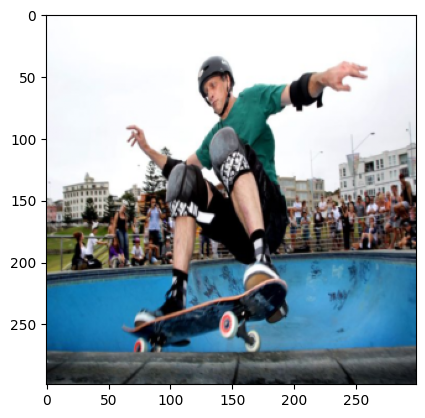

In [95]:
plt.imshow(img)

In [96]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a man doing a trick on a skateboard .
a man doing a trick on a skateboard .
a man doing a trick on a skateboard .
a man riding a skateboard down a ramp .
a man riding a skateboard on a skateboard .
a man riding a skateboard down a ramp .
a man is doing a trick on a skateboard .
a man doing a trick on a skateboard .
a man doing a trick on a skateboard .
a man is doing a trick on a skateboard .


--2025-10-29 16:45:15--  https://images.cnscdn.com/4/3/8/1/4381d0a8fff87d7c8ca6e45007d38d0e/original.jpg
Resolving images.cnscdn.com (images.cnscdn.com)... 2a06:98c1:3123:8000::, 2a06:98c1:3122:8000::, 8.47.69.0, ...
Connecting to images.cnscdn.com (images.cnscdn.com)|2a06:98c1:3123:8000::|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66786 (65K) [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>]  65.22K  --.-KB/s    in 0.05s   

2025-10-29 16:45:16 (1.37 MB/s) - ‘data/img.jpg’ saved [66786/66786]



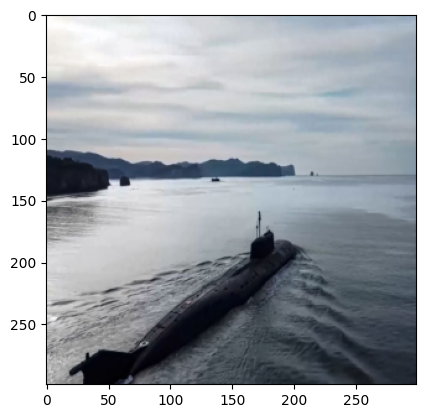

a person riding a surfboard on a wave .
a man riding a surfboard on top of a wave .
a man riding a skateboard down a ramp .
a man is riding a wave on the beach .
a man riding a surfboard on top of a wave .
a person riding a surfboard on the beach .
a man riding a surfboard on a beach .
a man riding a wave on a surfboard .
a man riding a surfboard on top of a wave .
a man riding a wave on top of a surfboard .


In [97]:
!wget https://images.cnscdn.com/4/3/8/1/4381d0a8fff87d7c8ca6e45007d38d0e/original.jpg -O data/img.jpg
img = plt.imread('data/img.jpg')
img = imresize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

### 5. Demo (2.5 балла)
##### **Найдите как минимум 10 изображений для теста.**

* Серьёзно, это часть задания — подготовьте хотя бы 10 картинок для генерации подписей.

* Сначала проверьте работу модели на простых изображениях, прежде чем переходить к более сложным.

* В вашем наборе должны быть примеры как удачных, так и неудачных подписей — проявите креативность :)

* Используйте фотографии, а не анимацию, 3D или рисунки — иначе придётся переобучать CNN на аниме.

* Обратите внимание на соотношение сторон изображений.

--2025-10-29 16:47:18--  https://www.fotoprizer.ru/imgprev.php?id=398322
Resolving www.fotoprizer.ru (www.fotoprizer.ru)... 37.143.12.163
Connecting to www.fotoprizer.ru (www.fotoprizer.ru)|37.143.12.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg            [ <=>                ]  11.97K  --.-KB/s    in 0s      

2025-10-29 16:47:18 (86.0 MB/s) - ‘data/img.jpg’ saved [12254]



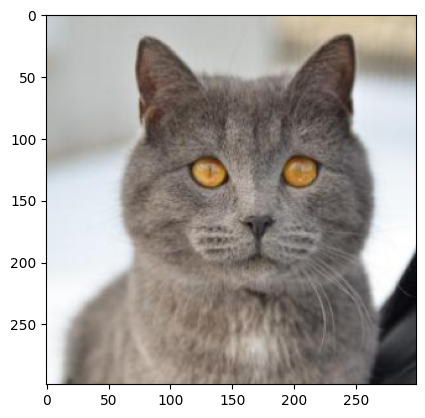

a cat sitting on a wooden floor near a window .
a cat sitting on a chair next to a cat .
a cat is sitting on a blanket on a bed .
a cat is sitting on a blanket on a bed .
a cat sitting on a wooden chair with a cat .
a cat is sitting on a blanket on a couch .
a cat is sitting on a blanket on a bed .
a cat is sitting on a white blanket .
a cat sitting on a bed next to a cat .
a cat sitting on a wooden floor .


In [98]:
!wget https://www.fotoprizer.ru/imgprev.php?id=398322 -O data/img.jpg
img = plt.imread('data/img.jpg')
img = imresize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

--2025-10-29 16:48:04--  https://img51994.kanal-o.ru/img/2020-06-29/fmt_81_24_shutterstock_547953349.jpg
Resolving img51994.kanal-o.ru (img51994.kanal-o.ru)... 176.99.3.196
Connecting to img51994.kanal-o.ru (img51994.kanal-o.ru)|176.99.3.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68551 (67K) [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>]  66.94K  --.-KB/s    in 0.01s   

2025-10-29 16:48:04 (4.79 MB/s) - ‘data/img.jpg’ saved [68551/68551]



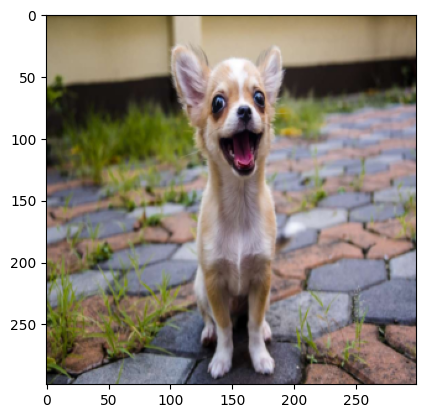

a dog is sitting on a bench in the water .
a dog is sitting on a bench with a dog .
a dog is sitting on a bench in the middle of a park .
a dog is laying on the ground with a dog .
a cat is sitting on a bench in the snow .
a dog is sitting on a bench in the middle of a street .
a dog is sitting on a bench in the snow .
a dog is sitting on a bench with a dog .
a dog is sitting on a bench near a white and black fire hydrant .
a dog is sitting on a bench next to a dog .


In [99]:
!wget https://img51994.kanal-o.ru/img/2020-06-29/fmt_81_24_shutterstock_547953349.jpg -O data/img.jpg
img = plt.imread('data/img.jpg')
img = imresize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

--2025-10-29 16:51:48--  https://a.d-cd.net/4SAAAgKyzuA-960.jpg
Resolving a.d-cd.net (a.d-cd.net)... 91.215.43.222
Connecting to a.d-cd.net (a.d-cd.net)|91.215.43.222|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 374931 (366K) [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>] 366.14K  --.-KB/s    in 0.02s   

2025-10-29 16:51:49 (15.8 MB/s) - ‘data/img.jpg’ saved [374931/374931]



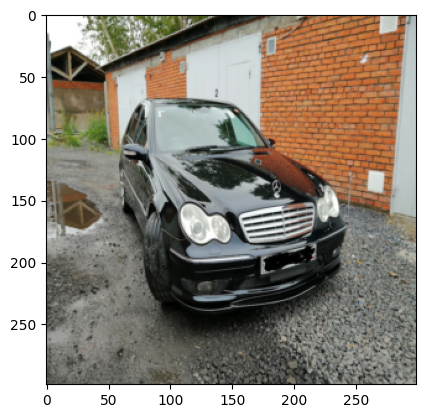

a motorcycle parked on the side of a road .
a motorcycle parked in front of a car .
a car parked in front of a car parked on the side of a road .
a motorcycle parked on the side of a road .
a car parked on a sidewalk with a lot of cars .
a motorcycle parked in front of a building .
a motorcycle parked on the side of a road .
a motorcycle parked in front of a building .
a motorcycle parked in front of a building .
a motorcycle parked in front of a building .


In [107]:
!wget https://a.d-cd.net/4SAAAgKyzuA-960.jpg -O data/img.jpg
img = plt.imread('data/img.jpg')
img = imresize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

--2025-10-29 16:52:10--  https://s14.stc.yc.kpcdn.net/share/i/12/14511519/wr-960.webp
Resolving s14.stc.yc.kpcdn.net (s14.stc.yc.kpcdn.net)... 2a11:27c0:10::182, 95.181.182.182
Connecting to s14.stc.yc.kpcdn.net (s14.stc.yc.kpcdn.net)|2a11:27c0:10::182|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278426 (272K) [image/webp]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>] 271.90K  --.-KB/s    in 0.05s   

2025-10-29 16:52:10 (4.95 MB/s) - ‘data/img.jpg’ saved [278426/278426]



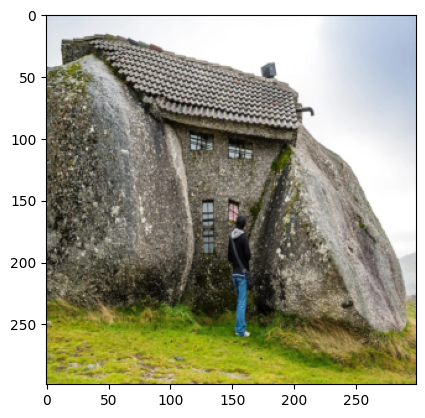

a man is standing in front of a building
a man is sitting on a bench near a tree .
a man is sitting on a bench with a dog .
a man is sitting on a bench in the snow .
a man is standing next to a fire hydrant .
a man sitting on a bench in front of a building .
a man is sitting on the bench in a park .
a man is standing in the middle of a street .
a man in a suit and a hat on a bench .
a man sitting on a bench with a dog on the ground .


In [109]:
!wget https://s14.stc.yc.kpcdn.net/share/i/12/14511519/wr-960.webp -O data/img.jpg
img = plt.imread('data/img.jpg')
img = imresize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

--2025-10-29 16:52:48--  https://bigfoto.name/photo/uploads/posts/2023-03/1679784236_bigfoto-name-p-raznie-doma-kartinki-22.jpg
Resolving bigfoto.name (bigfoto.name)... 185.184.192.62
Connecting to bigfoto.name (bigfoto.name)|185.184.192.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 364703 (356K) [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>] 356.16K  1.19MB/s    in 0.3s    

2025-10-29 16:52:49 (1.19 MB/s) - ‘data/img.jpg’ saved [364703/364703]



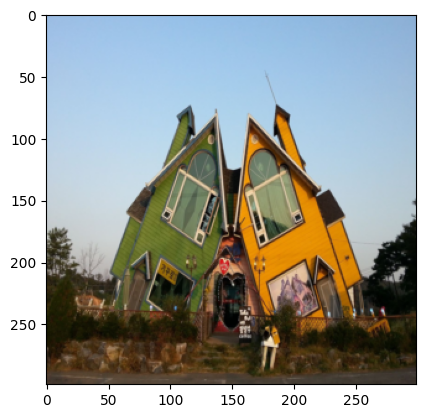

a group of people standing around a large truck .
a group of people standing in a field with a large clock .
a group of people standing in front of a large building .
a group of people standing next to a large building .
a group of people standing in a field near a building .
a group of people standing in front of a large building .
a group of people standing in front of a large building .
a group of people standing in a field with a large clock .
a group of people standing in the grass near a large building .
a group of people standing in a field near a fence .


In [110]:
!wget https://bigfoto.name/photo/uploads/posts/2023-03/1679784236_bigfoto-name-p-raznie-doma-kartinki-22.jpg -O data/img.jpg
img = plt.imread('data/img.jpg')
img = imresize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

--2025-10-29 16:54:05--  https://www.orangesmile.com/extreme/img/main/the-neptune-pool_1.jpg
Resolving www.orangesmile.com (www.orangesmile.com)... 172.233.33.167
Connecting to www.orangesmile.com (www.orangesmile.com)|172.233.33.167|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 195098 (191K) [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>] 190.53K  --.-KB/s    in 0.09s   

2025-10-29 16:54:06 (1.97 MB/s) - ‘data/img.jpg’ saved [195098/195098]



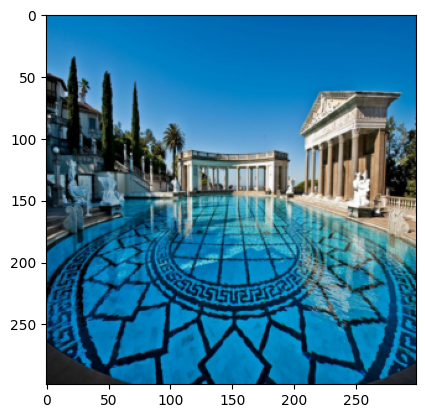

a red and white fire hydrant with a red and white clock .
a red and white fire hydrant sitting on a sidewalk .
a red and white fire hydrant sitting on a sidewalk .
a red fire hydrant with a red and red light .
a red and white fire hydrant on a sidewalk .
a red and white fire hydrant sitting on a sidewalk .
a red fire hydrant on a sidewalk next to a building .
a red fire hydrant with a red and white stripe on top of it .
a red and white fire hydrant sitting on the side of a road .
a red fire hydrant with a red and white clock on it .


In [112]:
!wget https://www.orangesmile.com/extreme/img/main/the-neptune-pool_1.jpg -O data/img.jpg
img = plt.imread('data/img.jpg')
img = imresize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

--2025-10-29 16:55:58--  https://lh5.googleusercontent.com/proxy/stuiSZYv65gKW9WOEGSbpeKVc4vTWEuez85m5Gl3Q-GViw94UdVnmUVmHxcRlgfgtTJLhEcyZrxTX-33N5Sa0pgNcmO7cn4
Resolving lh5.googleusercontent.com (lh5.googleusercontent.com)... 2a00:1450:4010:c0e::84, 173.194.73.132
Connecting to lh5.googleusercontent.com (lh5.googleusercontent.com)|2a00:1450:4010:c0e::84|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 75385 (74K) [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>]  73.62K  --.-KB/s    in 0.08s   

2025-10-29 16:55:59 (897 KB/s) - ‘data/img.jpg’ saved [75385/75385]



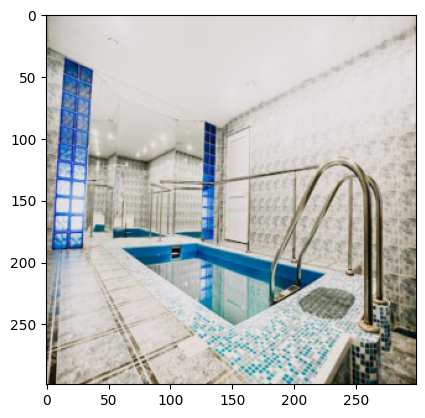

a man sitting on a bench in the middle of a park .
a man sitting on a bench in a park .
a man is sitting on a bench in the snow .
a small child is sitting on the ground .
a man sitting on a bench with a dog on the ground .
a man sitting on a bench with a dog .
a man is sitting on a bench in the snow .
a person on a skateboard in the air .
a man with a red shirt and a red shirt and a white shirt .
a man on a boat in the water .


In [113]:
!wget https://lh5.googleusercontent.com/proxy/stuiSZYv65gKW9WOEGSbpeKVc4vTWEuez85m5Gl3Q-GViw94UdVnmUVmHxcRlgfgtTJLhEcyZrxTX-33N5Sa0pgNcmO7cn4 -O data/img.jpg
img = plt.imread('data/img.jpg')
img = imresize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

--2025-10-29 16:57:17--  https://thumbs.dreamstime.com/b/%D1%82%D0%BE%D0%BB%D0%BF%D0%B0-%D0%BB%D1%8E%D0%B4%D0%B5%D0%B9-%D0%BD%D0%B0-%D0%BF%D0%B5%D1%88%D0%B5%D1%85%D0%BE%D0%B4%D0%BD%D0%BE%D0%BC-%D0%BF%D0%B5%D1%80%D0%B5%D1%85%D0%BE%D0%B4%D0%B5-%D0%B2-%D0%B3%D0%BE%D1%80%D0%BE%D0%B4%D0%B5-%D1%81%D0%B2%D0%B5%D1%80%D1%85%D1%83-%D1%80%D0%B0%D1%81%D1%81%D1%82%D1%80%D0%B5%D0%BB%D1%8F%D0%BB%D0%B0-223324992.jpg
Resolving thumbs.dreamstime.com (thumbs.dreamstime.com)... 146.75.117.91
Connecting to thumbs.dreamstime.com (thumbs.dreamstime.com)|146.75.117.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78163 (76K) [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>]  76.33K  --.-KB/s    in 0.05s   

2025-10-29 16:57:18 (1.60 MB/s) - ‘data/img.jpg’ saved [78163/78163]



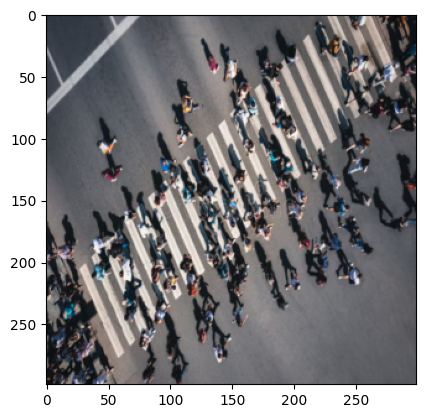

a group of people standing in the snow .
a group of people standing in the snow .
a group of people standing on a snowy hill .
a group of people standing in the snow .
a group of people standing on a snowy hill .
a group of people standing on a snow covered slope .
a group of people standing on a snow covered slope .
a group of people standing in the snow .
a group of people standing in the snow .
a group of people are standing in the snow .


In [114]:
!wget https://thumbs.dreamstime.com/b/%D1%82%D0%BE%D0%BB%D0%BF%D0%B0-%D0%BB%D1%8E%D0%B4%D0%B5%D0%B9-%D0%BD%D0%B0-%D0%BF%D0%B5%D1%88%D0%B5%D1%85%D0%BE%D0%B4%D0%BD%D0%BE%D0%BC-%D0%BF%D0%B5%D1%80%D0%B5%D1%85%D0%BE%D0%B4%D0%B5-%D0%B2-%D0%B3%D0%BE%D1%80%D0%BE%D0%B4%D0%B5-%D1%81%D0%B2%D0%B5%D1%80%D1%85%D1%83-%D1%80%D0%B0%D1%81%D1%81%D1%82%D1%80%D0%B5%D0%BB%D1%8F%D0%BB%D0%B0-223324992.jpg -O data/img.jpg
img = plt.imread('data/img.jpg')
img = imresize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

--2025-10-29 16:58:29--  https://s.mediasalt.ru/cache/content/data/images/507/507590/original.jpg
Resolving s.mediasalt.ru (s.mediasalt.ru)... 185.127.27.12
Connecting to s.mediasalt.ru (s.mediasalt.ru)|185.127.27.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45855 (45K) [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>]  44.78K  --.-KB/s    in 0.01s   

2025-10-29 16:58:30 (3.86 MB/s) - ‘data/img.jpg’ saved [45855/45855]



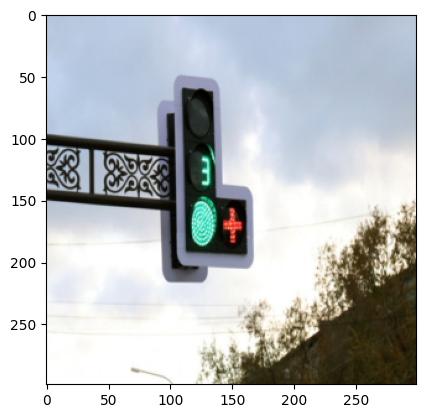

a red light on a street corner with a traffic light .
a red light is on the side of a street .
a traffic light with a red light in the background .
a red light is on a street corner .
a traffic light on a pole near a street .
a street sign on a pole in the middle of a city .
a red light is on a pole with a traffic light .
a red light is on a street corner .
a street sign on a pole with a blue sky in the background .
a street sign on a pole in front of a building .


In [115]:
!wget https://s.mediasalt.ru/cache/content/data/images/507/507590/original.jpg -O data/img.jpg
img = plt.imread('data/img.jpg')
img = imresize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

--2025-10-29 16:59:09--  https://blog.ufs-online.ru/media/3994/133701140_768467204013226_7991959900526399843_n.jpg
Resolving blog.ufs-online.ru (blog.ufs-online.ru)... 185.169.155.186
Connecting to blog.ufs-online.ru (blog.ufs-online.ru)|185.169.155.186|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159734 (156K) [image/jpeg]
Saving to: ‘data/img.jpg’

data/img.jpg        100%[===================>] 155.99K  --.-KB/s    in 0.02s   

2025-10-29 16:59:09 (9.38 MB/s) - ‘data/img.jpg’ saved [159734/159734]



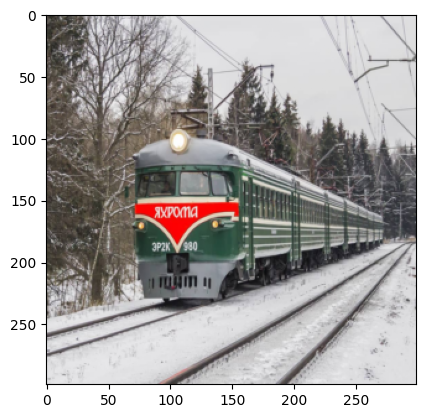

a train is traveling down the track in the station .
a train traveling down a track near a train station .
a train on a track with a train on the tracks
a train on a track with a train station .
a train is going down the track in the station .
a train on a track with a train .
a train is coming down the tracks in the station .
a train is coming down the track .
a train is traveling down the tracks near a train .
a train is coming down the tracks near a train .


In [116]:
!wget https://blog.ufs-online.ru/media/3994/133701140_768467204013226_7991959900526399843_n.jpg -O data/img.jpg
img = plt.imread('data/img.jpg')
img = imresize(img, (299, 299)).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))


![img](https://cs7.pikabu.ru/images/big_size_comm_an/2018-09_3/1536865148163644198.gif)

> Примечание: Это задание адаптировано по материалам курса "Deep Learning" (Skoltech).


In [ ]:
#!rm -r data/